In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 9

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 15:47:36 2026


In [2]:
Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Lifetime_Scenarios = ['Constant','Longer']

Sectors = ['Battery','S&A','C&C','MAG','CAT','PI&E','OTH']
New_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs','B-ESS','B-EVs']
Old_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs']
Agg_Sectors = ['Metal Goods & Others','B-CEs','B-EVs','B-ESS']

## 橘色系
sector_color_dict = {'S&A': '#FDD0A2',
                     'C&C': '#FDAE6B',
                     'MAG': '#FD8D3C',
                     'CAT': '#F16913',
                     'PI&E': '#D94801',
                     'OTH': '#8C2D04', 
                     
                     'Metal Goods & Others':'#FDD0A2', 
                     
                     'B-CEs': '#FDAE6B',
                     'B-EVs': '#F16913',
                     'B-ESS': '#8C2D04',  }

New_Sector_Colors = [sector_color_dict[s] for s in New_Sectors]
Old_Sector_Colors = [sector_color_dict[s] for s in Old_Sectors]
Agg_Sector_Colors = [sector_color_dict[s] for s in Agg_Sectors]

## Demand: Top-down (Traditional use)
- population (million persons)

In [3]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop = df_pop.loc[1988:,:]
df_pop.head(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
1988,1107.2576,122.578,469.330777,244.499,3119.997850,5063.663227
1989,1124.3362,123.069,470.873908,246.819,3186.878624,5151.976732


- per capita traditional use (kg/1000 persons)

In [4]:
df_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_per_capita.head(2)

,B-CEs,S&A,C&C,MAG,CAT,PI&E,OTH,Total
Sector,,,,,,,,
1988,0.767447,0.948708,0.521633,0.335234,0.323229,0.398726,1.109249,4.404226
1989,1.465547,1.820370,0.746412,0.643243,0.620410,0.765071,1.587239,7.648293


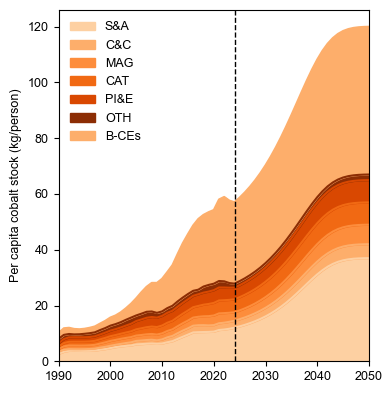

In [5]:
def plot_per_capita(df):
    year_min = 1990
    
    fig, ax = plt.subplots(1,1, figsize=(4, 4))
    df.plot.area(ax=ax, y=Old_Sectors, color=Old_Sector_Colors, legend=True)
            
    ax.set_xlim(year_min, 2050)
    ax.set_xticks(np.arange(year_min, 2051, 10))
    
    ax.set_ylabel('Per capita cobalt stock (kg/person)')
    ax.set_xlabel('')
    ax.axvline(x=2024, color="black", linestyle="--", lw=1)
    
    plt.legend(frameon=False)
    
    #plt.savefig(file_path + 'Sector_Cu_Ni_Co/Cobalt_per_capita_stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.tight_layout()
    plt.show()
    
    
plot_per_capita(df_per_capita)

- lifetime (normal distribution)

In [6]:
df_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=[2])
df_lifetime = df_lifetime.T
df_lifetime.head(2)

Lifetime Constant                                                  Longer  \
Sector    Battery B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH Battery   
1988          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   
1989          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   

Lifetime                                                  
Sector   B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH  
1988       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0  
1989       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0

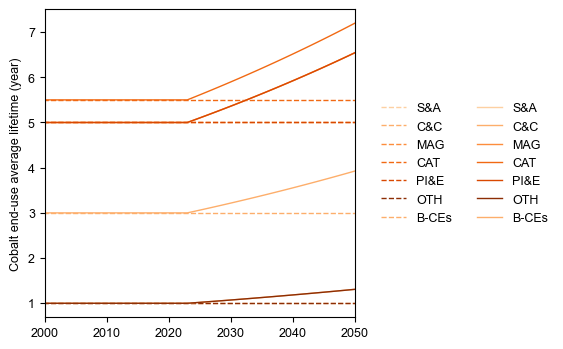

In [7]:
def plot_lifetime(df):
    year_min = 2000
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for sector in Old_Sectors:
        ax.plot(df.index, df['Constant',sector], label=sector, color=sector_color_dict[sector], lw=1, linestyle='--')
        
    for sector in Old_Sectors:
        ax.plot(df.index, df['Longer',sector], label=sector, color=sector_color_dict[sector], lw=1)
        
    ax.set_ylabel('Cobalt end-use average lifetime (year)')
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,10))
    ax.legend(frameon=False, ncol=2, loc='center left', bbox_to_anchor=(1.05,0.5))
    #plt.savefig(file_path + 'Sector_Cu_Ni_Co/Cobalt_Enduse_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_lifetime)

- Traditional use
- stock, inflow, outflow
- million persons * kg/1000 person = t
- from t to kt

In [8]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                             columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s] / 1000  ## from t to kt
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_traditional_stock, df_traditional_inflow, df_traditional_outflow = cal_traditional_stock_flow(df_pop, df_per_capita, df_lifetime)
df_traditional_inflow.tail(2)

Lifetime  Constant                                                         \
Sector         S&A        C&C        MAG        CAT       PI&E        OTH   
Sector                                                                      
2049      61.92074  30.418709  11.716639  12.278807  13.390125  12.170797   
2050      62.16483  30.539208  11.764195  12.331159  13.444286  12.216947   

Lifetime                 Longer                                             \
Sector         B-CEs        S&A        C&C       MAG        CAT       PI&E   
Sector                                                                       
2049      138.780657  50.593974  25.351530  9.563650  10.053514  10.930543   
2050      139.262225  50.364001  25.288849  9.522207  10.004073  10.882635   

Lifetime                         
Sector          OTH       B-CEs  
Sector                           
2049      10.143008  113.262851  
2050      10.116422  112.663952

In [9]:
df_traditional_stock.tail(2)

Lifetime    Constant                                                         \
Sector           S&A        C&C        MAG        CAT       PI&E        OTH   
Sector                                                                        
2049      336.913616  45.561394  63.772887  72.911132  72.902092  18.231786   
2050      338.441136  45.748454  64.042549  73.202744  73.199087  18.302305   

Lifetime                  Longer                                              \
Sector         B-CEs         S&A        C&C        MAG        CAT       PI&E   
Sector                                                                         
2049      483.007699  336.913616  45.561394  63.772887  72.911132  72.902092   
2050      484.956633  338.441136  45.748454  64.042549  73.202744  73.199087   

Lifetime                         
Sector          OTH       B-CEs  
Sector                           
2049      18.231786  483.007699  
2050      18.302305  484.956633

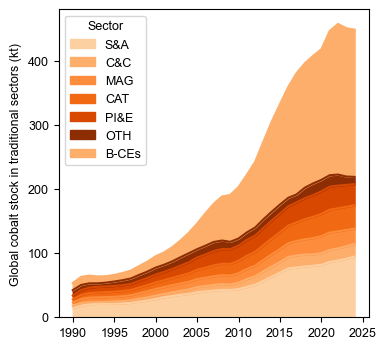

In [10]:
def plot_stock(df):
    year_min = 1990
    
    fig, ax = plt.subplots(1,1, figsize = (4,4))
    year_min = 1990
    df = df.loc[year_min:2024,'Constant']
    
    df.plot.area(ax=ax, y=Old_Sectors, color=Old_Sector_Colors)
    
    #ax.set_xlim(year_min,2050)
    ax.set_xlabel('')
    #ax.set_xticks(np.arange(year_min,2051,10))
    ax.set_ylabel('Global cobalt stock in traditional sectors (kt)')
    #ax.set_ylim(0,2700)
        
    #plt.savefig(file_path + 'Sector_Cu_Ni_Co/Cobalt_Traditional_Stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_stock(df_traditional_stock)

## Demand: Bottom-up (Emerging use)

In [11]:
def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(1988,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [12]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = df_ESS_stock['Cobalt']
df_ESS_stock = full_fill(df_ESS_stock)
df_ESS_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario             APS                                              \
Battery Scenario    Baseline                                               
Lifetime            Constant                                               
Region                 China         EU     Japan         RoW        USA   
2049              153.270757  55.080727  4.825730  240.017231  90.900664   
2050              155.026844  57.743485  5.028452  252.254392  91.898433   

ESS Scenario                                                              ...  \
Battery Scenario                                                          ...   
Lifetime              Longer                                              ...   
Region                 China         EU     Japan         RoW        USA  ...   
2049              153.270757  55.080727  4.825730  240.017231  90.900664  ...   
2050              155.026844  57.743485  5.028452  252.254392  91.898433  ...   

ESS Scenario          STEPS                                           \
Battery Scenario  Optimized                                            
Lifetime           Constant                                            
Region                China        EU     Japan        RoW       USA   
2049              17.273901  4.339176  0.211883  12.243238  9.503814   
2050              18.077786  4.685404  0.216032  13.126649  9.908523   

ESS Scenario                                                          
Battery Scenario                                                      
Lifetime             Longer                                           
Region                China        EU     Japan        RoW       USA  
2049              17.609833  4.366187  0.221317  12.287643  9.714831  
2050              17.974436  4.633560  0.218752  12.935902  9.864924  

[2 rows x 180 columns]

In [13]:
df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = df_ESS_inflow['Cobalt']
df_ESS_inflow = full_fill(df_ESS_inflow)
df_ESS_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                           \
Battery Scenario   Baseline                                            
Lifetime           Constant                                            
Region                China        EU     Japan        RoW       USA   
2049              15.139273  6.603474  0.554706  28.967890  9.177447   
2050              15.574010  6.828924  0.568572  30.122907  9.308635   

ESS Scenario                                                         ...  \
Battery Scenario                                                     ...   
Lifetime            Longer                                           ...   
Region               China        EU     Japan        RoW       USA  ...   
2049              9.208293  4.762136  0.428091  20.660257  5.802808  ...   
2050              9.380984  4.839881  0.427124  21.141662  5.827168  ...   

ESS Scenario         STEPS                                                    \
Battery Scenario Optimized                                                     
Lifetime          Constant                                            Longer   
Region               China        EU     Japan       RoW       USA     China   
2049              2.064946  0.593945  0.022004  1.626902  1.124016  1.376047   
2050              2.165833  0.630489  0.022613  1.727843  1.172957  1.425466   

ESS Scenario                                              
Battery Scenario                                          
Lifetime                                                  
Region                  EU     Japan       RoW       USA  
2049              0.441012  0.014582  1.150909  0.739832  
2050              0.459325  0.014755  1.203629  0.764510  

[2 rows x 180 columns]

In [14]:
df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = df_ESS_outflow['Cobalt']
df_ESS_outflow = full_fill(df_ESS_outflow)
df_ESS_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                           \
Battery Scenario   Baseline                                            
Lifetime           Constant                                            
Region                China        EU     Japan        RoW       USA   
2049              13.383185  3.940717  0.351984  16.730729  8.179678   
2050              13.817923  4.166167  0.365850  17.885746  8.310866   

ESS Scenario                                                        ...  \
Battery Scenario                                                    ...   
Lifetime            Longer                                          ...   
Region               China        EU     Japan       RoW       USA  ...   
2049              7.452205  2.099379  0.225369  8.423096  4.805040  ...   
2050              7.624897  2.177123  0.224401  8.904501  4.829399  ...   

ESS Scenario         STEPS                                                    \
Battery Scenario Optimized                                                     
Lifetime          Constant                                            Longer   
Region               China        EU     Japan       RoW       USA     China   
2049              1.351584  0.269736  0.019049  0.804436  0.769505  1.167958   
2050              1.361948  0.284261  0.018464  0.844432  0.768248  1.060863   

ESS Scenario                                              
Battery Scenario                                          
Lifetime                                                  
Region                  EU     Japan       RoW       USA  
2049              0.202108  0.019435  0.588079  0.681808  
2050              0.191952  0.017320  0.555370  0.614417  

[2 rows x 180 columns]

- vehicle: battery material (kt)

In [15]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = df_EV_stock['Cobalt']
df_EV_stock = full_fill(df_EV_stock)
df_EV_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario          APS                                        \
Segment Scenario        Baseline                                         
Battery Size              Larger                                         
Battery Scenario        Baseline                                         
Lifetime                Constant                                         
Region                     China           EU       Japan          RoW   
2049                 1775.264709  1834.098402  197.557399  4602.470037   
2050                 1858.904158  1911.745334  207.903169  5018.585112   

Powertrain Scenario                                                     \
Segment Scenario                                                         
Battery Size                                                             
Battery Scenario                                                         
Lifetime                               Longer                            
Region                       USA        China           EU       Japan   
2049                 1154.982334  1707.224016  1754.280375  186.471378   
2050                 1241.672510  1783.293133  1832.499738  195.904146   

Powertrain Scenario                            ...       STEPS             \
Segment Scenario                               ...    Baseline              
Battery Size                                   ...      Larger              
Battery Scenario                               ...   Optimized              
Lifetime                                       ...    Constant              
Region                       RoW          USA  ...       China         EU   
2049                 4345.561671  1100.987117  ...  124.311459  91.311167   
2050                 4729.879957  1181.221045  ...  129.289564  99.196679   

Powertrain Scenario                                                           \
Segment Scenario                                                               
Battery Size                                                                   
Battery Scenario                                                               
Lifetime                                                   Longer              
Region                   Japan         RoW        USA       China         EU   
2049                  9.622316  195.042691  46.125761  120.172227  84.129456   
2050                 10.473324  216.797221  49.826811  123.545877  90.515858   

Powertrain Scenario                                   
Segment Scenario                                      
Battery Size                                          
Battery Scenario                                      
Lifetime                                              
Region                  Japan         RoW        USA  
2049                 8.647599  179.549412  43.451564  
2050                 9.330424  198.117535  46.482874  

[2 rows x 180 columns]

In [16]:
df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = df_EV_inflow['Cobalt']
df_EV_inflow = full_fill(df_EV_inflow)
df_EV_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario         APS                                     \
Segment Scenario       Baseline                                      
Battery Size             Larger                                      
Battery Scenario       Baseline                                      
Lifetime               Constant                                      
Region                    China          EU      Japan         RoW   
2049                 249.308327  252.710869  28.262255  745.905316   
2050                 259.778746  259.316385  29.537125  804.209390   

Powertrain Scenario                                                 \
Segment Scenario                                                     
Battery Size                                                         
Battery Scenario                                                     
Lifetime                             Longer                          
Region                      USA       China          EU      Japan   
2049                 178.327657  162.939429  163.488705  18.263170   
2050                 190.107210  166.963409  165.656084  18.795773   

Powertrain Scenario                          ...      STEPS             \
Segment Scenario                             ...   Baseline              
Battery Size                                 ...     Larger              
Battery Scenario                             ...  Optimized              
Lifetime                                     ...   Constant              
Region                      RoW         USA  ...      China         EU   
2049                 520.143331  121.994324  ...  16.960945  14.592833   
2050                 553.408091  128.357540  ...  17.553257  15.727081   

Powertrain Scenario                                                       \
Segment Scenario                                                           
Battery Size                                                               
Battery Scenario                                                           
Lifetime                                               Longer              
Region                  Japan        RoW       USA      China         EU   
2049                 1.547121  33.656800  7.230700  10.763849   9.692134   
2050                 1.665398  36.975679  7.762206  10.942962  10.295443   

Powertrain Scenario                                 
Segment Scenario                                    
Battery Size                                        
Battery Scenario                                    
Lifetime                                            
Region                  Japan        RoW       USA  
2049                 1.009003  23.400668  4.861129  
2050                 1.068484  25.367717  5.147169  

[2 rows x 180 columns]

In [17]:
df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = df_EV_outflow['Cobalt']
df_EV_outflow = full_fill(df_EV_outflow)
df_EV_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_2800\689255960.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario         APS                                     \
Segment Scenario       Baseline                                      
Battery Size             Larger                                      
Battery Scenario       Baseline                                      
Lifetime               Constant                                      
Region                    China          EU      Japan         RoW   
2049                 166.959749  170.212193  18.020825  348.657715   
2050                 176.139297  181.669453  19.191354  388.094315   

Powertrain Scenario                                                          \
Segment Scenario                                                              
Battery Size                                                                  
Battery Scenario                                                              
Lifetime                            Longer                                    
Region                      USA      China         EU     Japan         RoW   
2049                  94.830308  88.366492  82.484165  8.943653  155.281470   
2050                 103.417034  90.894292  87.436721  9.363004  169.089805   

Powertrain Scenario             ...      STEPS                                 \
Segment Scenario                ...   Baseline                                  
Battery Size                    ...     Larger                                  
Battery Scenario                ...  Optimized                                  
Lifetime                        ...   Constant                                  
Region                     USA  ...      China        EU     Japan        RoW   
2049                 45.148051  ...  12.032258  7.131827  0.734996  13.399411   
2050                 48.123612  ...  12.575151  7.841569  0.814391  15.221149   

Powertrain Scenario                                                    \
Segment Scenario                                                        
Battery Size                                                            
Battery Scenario                                                        
Lifetime                         Longer                                 
Region                    USA     China        EU     Japan       RoW   
2049                 3.726745  8.026816  3.937218  0.383016  6.555146   
2050                 4.061156  7.569312  3.909041  0.385659  6.799594   

Powertrain Scenario            
Segment Scenario               
Battery Size                   
Battery Scenario               
Lifetime                       
Region                    USA  
2049                 2.152268  
2050                 2.115859  

[2 rows x 180 columns]

## Cobalt cycle
- loss rate

In [18]:
df_loss_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='loss rate', index_col=[0,1,2], header=[2])
df_loss_rate = df_loss_rate.T
df_loss_rate.tail(2)

Scenario  Constant                                                             \
Stage       Mining Refining Manufacturing                                       
Loss rate      All      All       Battery B-EVs B-ESS B-CEs   S&A   C&C   MAG   
2049          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   
2050          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   

Scenario         ...     Efficient                                          \
Stage            ... Manufacturing                                           
Loss rate   CAT  ...       Battery     B-EVs     B-ESS     B-CEs       S&A   
2049       0.05  ...      0.007778  0.007778  0.007778  0.007778  0.044382   
2050       0.05  ...      0.007700  0.007700  0.007700  0.007700  0.042163   

Scenario                                                     
Stage                                                        
Loss rate       C&C       MAG       CAT      PI&E       OTH  
2049       0.007778  0.015556  0.038891  0.007778  0.007778  
2050       0.007700  0.015401  0.038502  0.007700  0.007700  

[2 rows x 24 columns]

- recycling rate

In [19]:
df_recycling_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='recycling rate', index_col=[0,1,2], header=[2])
df_recycling_rate = df_recycling_rate.T
df_recycling_rate.tail(2)

Scenario                   Constant                                         \
Recycling New scrap generation rate                                          
Sector                      Battery B-EVs B-ESS B-CEs   S&A  C&C  MAG  CAT   
2049                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   
2050                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   

Scenario             ...               High                                \
Recycling            ... EoL recycling rate                                 
Sector    PI&E  OTH  ...            Battery     B-EVs     B-ESS     B-CEs   
2049       0.0  0.0  ...           0.928775  0.928775  0.928775  0.128243   
2050       0.0  0.0  ...           0.928775  0.928775  0.928775  0.129526   

Scenario                                                
Recycling                                               
Sector          S&A       C&C       MAG  CAT PI&E  OTH  
2049       0.928775  0.577094  0.128243  0.0  0.0  0.0  
2050       0.928775  0.582865  0.129526  0.0  0.0  0.0  

[2 rows x 60 columns]

- statistics (from t to kt)

In [20]:
df_world_statistics = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='world statistics', index_col=[0], header=2)
df_world_statistics = df_world_statistics / 1000  ## from ton to kt
df_world_statistics.head(2)

,mine_production,refining_production,secondary_production
Year,,,
1988,43.039,26.700,NaN
1989,42.430,25.516,NaN


- Surplus

In [21]:
df_surplus = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Surplus', index_col=[0], header=[3])
df_surplus.fillna(value=0, inplace=True)
df_surplus = df_surplus / 1000  ## from ton to kt
df_surplus.loc[2020:2025]

,Cobalt surplus,Battery surplus
2020,0.0,0.0
2021,0.0,0.0
2022,0.0,14.2
2023,0.0,25.0
2024,0.0,36.0
2025,0.0,0.0


In [22]:
def rename_sector(s):
    if s in ['B-ESS','B-EVs','B-CEs']:
        return s
    else:
        return 'Metal Goods & Others'
    
    
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T
    df['Sector'] = df.index
    df.Sector = df.Sector.apply(rename_sector)
    df = df.groupby(['Sector']).sum().T
    
    return df

In [23]:
def extract_all_sectors(df_traditional, df_ess, df_battery):
    
    df_output = pd.DataFrame(index=df_pop.index, columns=New_Sectors)
    
    ## fill traditional use
    for s in Old_Sectors:
        ## Lifetime, Sector
        df_output[s] = df_traditional['Constant',s]
        
    ## fill ESS
    ## ESS Scenario, Battery Scenario, Lifetime, Region
    df_output['B-ESS'] = df_ess['APS','Baseline','Constant'].sum(axis=1)
        
    ## fill vehicle (battery + component)
    ## Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    df_output['B-EVs'] = df_battery['APS','Baseline','Larger','Baseline','Constant'].sum(axis=1)
        
    return df_output


df_sectors_inflow = extract_all_sectors(df_traditional_inflow, df_ESS_inflow, df_EV_inflow)
df_sectors_inflow.tail(2)

,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
Region,,,,,,,,,
2049,61.92074,30.418709,11.716639,12.278807,13.390125,12.170797,138.780657,60.442790,1454.514422
2050,62.16483,30.539208,11.764195,12.331159,13.444286,12.216947,139.262225,62.403048,1542.948857


In [24]:
df_sectors_inflow_2 = reconstruct_sector(df_sectors_inflow)
df_sectors_inflow_2.tail(2)

Sector,B-CEs,B-ESS,B-EVs,Metal Goods & Others
Region,,,,
2049,138.780657,60.442790,1454.514422,141.895818
2050,139.262225,62.403048,1542.948857,142.460625


In [25]:
df_sectors_inflow_2.loc[2000:2024,:]

Sector,B-CEs,B-ESS,B-EVs,Metal Goods & Others
Region,,,,
2000,6.098598,0.000000,0.000000,24.330936
2001,5.754880,0.000000,0.000000,23.976839
2002,7.863026,0.000000,0.000000,26.264731
2003,9.590170,0.000000,0.000000,28.941997
2004,11.903859,0.000000,0.000000,30.830287
2005,15.073729,0.000000,0.014960,32.850670
2006,19.358437,0.000000,0.000013,32.848293
2007,19.998234,0.000000,0.000053,34.281684
2008,23.063789,0.000000,0.019654,32.377139


In [26]:
df_sectors_inflow_2.loc[2000:2024,:].sum()

Sector
B-CEs                    933.805090
B-ESS                     20.205257
B-EVs                    264.295411
Metal Goods & Others    1061.864943
dtype: float64

In [27]:
df_sectors_outflow = extract_all_sectors(df_traditional_outflow, df_ESS_outflow, df_EV_outflow)
df_sectors_outflow_2 = reconstruct_sector(df_sectors_outflow)
df_sectors_outflow.tail(2)

,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
Region,,,,,,,,,
2049,60.092456,30.212122,11.411139,11.964354,13.064398,12.097179,136.661793,42.586293,798.680791
2050,60.637309,30.352148,11.494534,12.039547,13.147290,12.146428,137.313291,44.546551,868.511454


In [28]:
df_sectors_outflow_2.loc[2000:2024,:]

Sector,B-CEs,B-ESS,B-EVs,Metal Goods & Others
Region,,,,
2000,3.873742,0.000000,0.000000,18.099029
2001,4.320617,0.000000,0.000000,19.580099
2002,4.929075,0.000000,0.000000,20.955390
2003,5.555383,0.000000,0.000000,22.402127
2004,6.108294,0.000000,0.000000,24.631025
2005,7.105146,0.000000,0.000006,26.561255
2006,8.801605,0.000000,0.000020,27.416615
2007,10.968278,0.000000,0.000066,28.404548
2008,13.737583,0.000000,0.000194,30.172995


In [29]:
df_sectors_stock = extract_all_sectors(df_traditional_stock, df_ESS_stock, df_EV_stock)
df_sectors_stock_2 = reconstruct_sector(df_sectors_stock)
df_sectors_stock.tail(2)

,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
Region,,,,,,,,,
2049,336.913616,45.561394,63.772887,72.911132,72.902092,18.231786,483.007699,544.095109,9564.372880
2050,338.441136,45.748454,64.042549,73.202744,73.199087,18.302305,484.956633,561.951606,10238.810283


In [30]:
df_temp = df_sectors_inflow_2.loc[2020:2024,:]
df_temp['B-CEs'] / df_temp.sum(axis=1) * 100

Region
2020    45.393990
2021    44.971846
2022    38.928293
2023    33.052871
2024    35.614329
dtype: float64

In [31]:
df_temp = df_sectors_stock_2.loc[2020:2024,:]
df_temp['B-CEs'] / df_temp.sum(axis=1)

Region
2020    0.418431
2021    0.409921
2022    0.386983
2023    0.350136
2024    0.320103
dtype: float64

In [32]:
df_sectors_stock_2.loc[2005:2024,:]

Sector,B-CEs,B-ESS,B-EVs,Metal Goods & Others
Region,,,,
2005,39.907734,0.000000,0.014954,106.276745
2006,50.464566,0.000000,0.014947,111.708423
2007,59.494522,0.000000,0.014933,117.585559
2008,68.820729,0.000000,0.034394,119.789703
2009,73.092504,0.000000,0.048482,117.844198
2010,80.429501,0.090125,0.068411,122.913274
2011,89.909092,0.127191,0.201502,132.493291
2012,102.631650,0.156549,0.407000,140.037834
2013,121.350486,0.203319,0.788541,152.922711


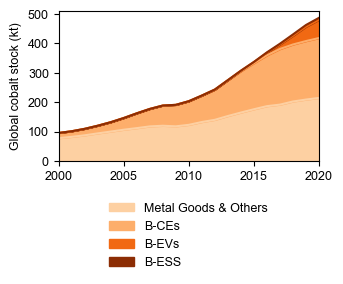

In [33]:
def plot_area(df, name):
    
    year_min=2000
    year_max=2020
    df = df.loc[year_min:year_max,]
    df.index = np.arange(year_min, year_max+1)
    
    fig, ax = plt.subplots(1,1, figsize=(3.5, 2))
    
    df_s = df.T.groupby(['Sector']).sum().T
    df_s.plot.area(ax=ax, y=Agg_Sectors, color=Agg_Sector_Colors, legend=False)

    ax.set_ylabel('Global cobalt '+ name +' (kt)')
    ax.set_xlim(year_min,year_max)
    #ax.set_ylim(0,460)
    ax.set_xlabel('')
    ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), frameon=False)
    #plt.savefig(file_path + r'Sector_Cu_Ni_Co\His_Cobalt.png', bbox_inches='tight', pad_inches=.1, dpi=300)

    plt.show()
    
    
plot_area(df_sectors_stock_2, 'stock')

In [34]:
def agg_world_results(df_inflow, df_stock, df_outflow, df_loss, df_recycling, df_stat, df_sur):
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_inflow.index)
    df_world['Inflow'] = df_inflow.sum(axis=1)
    df_world['P4_P5'] = df_inflow.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['Stock'] = df_stock.sum(axis=1)
    df_world['Outflow'] = df_outflow.sum(axis=1)
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in New_Sectors:
        df_old_sec[sector] = df_outflow[sector] * df_recycling[('Constant','EoL recycling rate',sector)]
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P3_P2'] = df_world['P6_P3']
    df_world['P6_E0'] = df_world['P5_P6'] - df_world['P6_P3']
    
    ################ 往前算
    df_manu = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_manu_recycle = df_manu.copy()
    for sector in New_Sectors:
        df_manu[sector] = df_inflow[sector] / (1 - df_loss[('Constant','Manufacturing',sector)])
        df_manu_recycle[sector] = df_manu[sector] * df_recycling[('Constant','New scrap generation rate',sector)] * df_recycling[('Constant','New scrap recycling efficiency',sector)]
        
    df_world['P4_P3'] = df_manu_recycle.sum(axis=1)
    df_world['P3_P4'] = df_world['P4_P3']
    df_world['P2_P4'] = df_manu.sum(axis=1) + df_sur['Battery surplus'] 
    df_world['P4_E0'] = df_world['P2_P4'] - df_world['P4_P5']
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1 - df_loss[('Constant','Refining','All')])
    df_world['P1_P2'] = df_world['P1_P2'] + df_sur['Cobalt surplus'] 
    df_world['P2_E0'] = df_world['P1_P2'] * df_loss[('Constant','Refining','All')]
                                                    
    df_world['L0_P1'] = df_world['P1_P2'] / (1 - df_loss[('Constant','Mining','All')])
    df_world['P1_E0'] = df_world['L0_P1'] - df_world['P1_P2']
    
    ################ 与统计数据进行比较
    df_world['Mining'] = df_stat['mine_production']
    df_world['Refining'] = df_stat['refining_production']
    
    df_world = df_world[['L0_P1','P1_P2','Mining','P2_P4','Refining','P4_P5','Inflow','Stock','Outflow','P5_P6',
                         'P6_P3','P4_P3','P3_P4','P3_P2',
                         'P1_E0','P2_E0','P4_E0','P6_E0']]
    
    return df_world
    

df_world_flow = agg_world_results(df_sectors_inflow, df_sectors_stock, df_sectors_outflow, df_loss_rate, df_recycling_rate, df_world_statistics, df_surplus)

df_world_flow['EoL-RR'] = df_world_flow['P6_P3'] / df_world_flow['Outflow'] 
df_world_flow['EoL-RIR'] = df_world_flow['P6_P3'] / df_world_flow['Inflow']
df_world_flow['Mining_Variance'] = (df_world_flow['P1_P2'] - df_world_flow['Mining']) / df_world_flow['Mining'] *100
df_world_flow['Refining_Variance'] = (df_world_flow['P2_P4'] - df_world_flow['Refining']) / df_world_flow['Refining'] *100
#df_world_flow.to_excel('test_Cobalt.xlsx')

In [35]:
pd.set_option('display.max_columns', None)
df_world_flow.loc[2020:2030,:]

,L0_P1,P1_P2,Mining,P2_P4,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,P1_E0,P2_E0,P4_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,
2020,223.250720,145.112968,142.251,139.807083,130.109,135.200000,135.200000,487.315822,110.772822,110.772822,23.716708,12.629388,12.629388,23.716708,78.137752,29.022594,4.607083,87.056114,0.214102,0.175419,2.011914,7.453814
2021,300.125978,195.081886,162.000,180.555637,166.600,175.000000,175.000000,549.703406,112.612416,112.612416,24.490128,14.929116,14.929116,24.490128,105.044092,39.016377,5.555637,88.122288,0.217473,0.139944,20.420917,8.376733
2022,320.355260,208.230919,198.000,192.055157,161.000,172.800000,172.800000,607.573831,114.929575,114.929575,25.470422,12.966531,12.966531,25.470422,112.124341,41.646184,19.255157,89.459153,0.221618,0.147398,5.167131,19.288918
2023,342.320638,222.508415,238.000,205.233538,180.000,175.000000,175.000000,661.376116,121.197715,121.197715,27.226807,13.527619,13.527619,27.226807,119.812223,44.501683,30.233538,93.970908,0.224648,0.155582,-6.509070,14.018632
2024,379.506131,246.678985,254.000,227.529847,222.000,186.010000,186.010000,718.267236,129.118880,129.118880,30.186659,14.204762,14.204762,30.186659,132.827146,49.335797,41.519847,98.932221,0.233790,0.162285,-2.882289,2.490922
2025,407.214453,264.689394,NaN,245.394718,NaN,238.904767,238.904767,823.877274,133.294729,133.294729,33.643203,15.928094,15.928094,33.643203,142.525058,52.937879,6.489952,99.651526,0.252397,0.140823,NaN,NaN
2026,438.430233,284.979651,NaN,265.406644,NaN,258.461170,258.461170,948.127631,134.210813,134.210813,37.422923,16.989165,16.989165,37.422923,153.450582,56.995930,6.945474,96.787890,0.278837,0.144791,NaN,NaN
2027,481.144639,312.744015,NaN,292.628287,NaN,285.173937,285.173937,1093.252265,140.049304,140.049304,42.433074,17.971162,17.971162,42.433074,168.400624,62.548803,7.454349,97.616229,0.302987,0.148797,NaN,NaN
2028,537.848989,349.601843,NaN,328.727558,NaN,320.681135,320.681135,1260.776570,153.156829,153.156829,49.046084,18.918249,18.918249,49.046084,188.247146,69.920369,8.046424,104.110745,0.320234,0.152943,NaN,NaN


In [36]:
df_world_flow.loc[2000:2024,:]

,L0_P1,P1_P2,Mining,P2_P4,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,P1_E0,P2_E0,P4_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,
2000,51.685080,33.595302,37.874,31.989200,36.016,30.429534,30.429534,95.282703,21.972770,21.972770,5.112958,4.962819,4.962819,5.112958,18.089778,6.719060,1.559666,16.859812,0.232695,0.168026,-11.297191,-11.180586
2001,49.620623,32.253405,47.915,31.385600,39.586,29.731719,29.731719,101.113707,23.900716,23.900716,5.582876,5.385501,5.385501,5.582876,17.367218,6.450681,1.653881,18.317840,0.233586,0.187775,-32.686204,-20.715404
2002,57.257456,37.217347,50.661,35.800000,41.654,34.127757,34.127757,109.356998,25.884466,25.884466,6.026123,5.225552,5.225552,6.026123,20.040110,7.443469,1.672243,19.858343,0.232808,0.176575,-26.536494,-14.053872
2003,64.897695,42.183501,52.898,40.289200,43.236,38.532167,38.532167,119.931654,27.957511,27.957511,6.542399,5.345334,5.345334,6.542399,22.714193,8.436700,1.757033,21.415112,0.234012,0.169791,-20.255016,-6.815617
2004,71.907616,46.739951,58.573,44.582000,48.527,42.734146,42.734146,131.926481,30.739320,30.739320,7.190040,5.518180,5.518180,7.190040,25.167666,9.347990,1.847854,23.549280,0.233904,0.168250,-20.202225,-8.129495
2005,81.438040,52.934726,63.350,50.183600,54.078,47.939359,47.939359,146.199433,33.666407,33.666407,7.835819,6.872808,6.872808,7.835819,28.503314,10.586945,2.244241,25.830588,0.232749,0.163453,-16.440843,-7.201450
2006,87.869449,57.115142,70.029,54.271600,53.770,52.206743,52.206743,162.187936,36.218240,36.218240,8.579486,5.936177,5.936177,8.579486,30.754307,11.423028,2.064857,27.638754,0.236883,0.164337,-18.440729,0.932862
2007,90.896399,59.082660,71.650,56.447600,53.291,54.279971,54.279971,177.095015,39.372892,39.372892,9.181472,6.272060,6.272060,9.181472,31.813740,11.816532,2.167629,30.191420,0.233193,0.169150,-17.539903,5.923327
2008,92.046910,59.830492,76.439,57.635600,57.291,55.460583,55.460583,188.644825,43.910773,43.910773,9.771207,6.278766,6.278766,9.771207,32.216419,11.966098,2.175017,34.139566,0.222524,0.176183,-21.727794,0.601491


In [37]:
df_world_flow.loc[2000:2024,:].sum()

L0_P1                3985.084952
P1_P2                2590.305219
Mining               2789.536000
P2_P4                2437.337315
Refining             2339.198000
P4_P5                2280.170701
Inflow               2280.170701
Stock                7698.751547
Outflow              1648.729405
P5_P6                1648.729405
P6_P3                 365.093141
P4_P3                 230.048413
P3_P4                 230.048413
P3_P2                 365.093141
P1_E0                1394.779733
P2_E0                 518.061044
P4_E0                 157.166614
P6_E0                1283.636264
EoL-RR                  5.588111
EoL-RIR                 4.109967
Mining_Variance      -281.352167
Refining_Variance      16.243806
dtype: float64

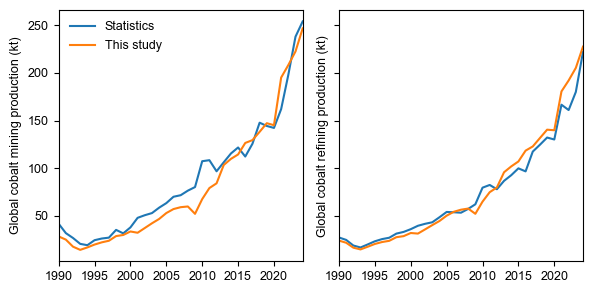

In [38]:
def plot_variance(df):
    
    year_min=1990
    year_max=2024
    df = df.loc[year_min:year_max,]
    
    fig, axes = plt.subplots(1,2, figsize=(6, 3), sharex=True, sharey=True)
    
    axes[0].plot(df.index, df.Mining, label='Statistics')
    axes[0].plot(df.index, df.P1_P2, label='This study')
    
    axes[1].plot(df.index, df.Refining, label='Statistics')
    axes[1].plot(df.index, df.P2_P4, label='This study')

    axes[0].set_ylabel('Global cobalt mining production (kt)')
    axes[1].set_ylabel('Global cobalt refining production (kt)')
    
    axes[0].legend(frameon=False)
    
    for ax in axes:
        ax.set_xlim(year_min,year_max)
        ax.set_xlabel('')
        ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()
    plt.savefig(file_path + 'Sector_Cu_Ni_Co/His_Cobalt_Variance.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()

    
plot_variance(df_world_flow)

In [39]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 0分钟 38秒
